<img src="images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# Convolutional Neural Networks &mdash; An Introduction

Images are an important source of information for many machine learning tasks, including image classification, object detection, and semantic segmentation. However, images have characteristics that make them fundamentally different from many traditional tabular data sets. They are typically high-dimensional, spatially structured, and contain strong local correlations: neighboring pixels are often related, while the meaning of a pixel depends heavily on its location and surrounding context. A basic multilayer perceptron (MLP) does not naturally account for these properties. After flattening an image into a vector, an MLP treats each pixel as an independent input feature and connects it to every neuron in the next layer. This can result in a very large number of parameters, while also making the model sensitive to small shifts or changes in the position of objects.

**Convolutional Neural Networks (CNNs)** address these challenges by incorporating ideas that are well suited to image data. To develop the intuition behind CNNs, this notebook first introduces the basic image convolution operation, a classical image-processing technique. In image convolution, a small kernel is moved across an image, and for each local image patch, a weighted sum of the pixel values is computed. Depending on the values in the kernel, this operation can highlight edges, sharpen images, blur regions, or detect other local patterns. The same kernel is applied at every image location, which allows the operation to detect a pattern regardless of where it occurs and keeps the number of parameters independent of the image size.

CNNs adopt this idea by treating the **convolution operation as a learnable linear layer**. Instead of using manually designed image-processing kernels, a CNN learns the kernel values during training. By applying multiple learned filters, a convolutional layer can detect different local features, such as edges, textures, and simple shapes. These feature maps can then be processed by additional convolutional layers, allowing the network to build increasingly complex representations from local patterns. The notebook concludes by presenting the general blueprint of CNN architectures, typically consisting of convolutional layers, optional pooling or other downsampling operations, nonlinear activation functions, and a final prediction component. It also briefly outlines common extensions, such as normalization layers, residual connections, and more advanced architectural designs.

This notebook is intended as a starting point for learning about CNNs and focuses on developing an intuitive understanding of their central ideas. It deliberately omits several important topics, including the detailed derivation of backpropagation through convolutional layers and practical examples of training CNNs on real data. Those topics are valuable next steps, but introducing them here would distract from the main goal: understanding why convolution is useful for images and how this operation forms the foundation of CNN architectures.

So let's get started!

### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

In [1]:
import numpy as np

from src.utils.data.media import *
from src.utils.plotting.media import *
from src.utils.plotting.math import *

#### Preliminaries

* This notebook assumes that you are familiar with basic neural networks, i.e., fully-connected networks, also often called Multilayer Perceptrons (MLP)
* This notebook is an introductory notebook focusing on motivation and core ideas. Mathematically details such as backpropagation through convolutional layers, full-fletched implementations and training of CNN models are beyond this scope of the notebook.

---

## Why CNNs?

To better understand the core ideas behind Convolutional Neural Networks (CNNs), it is useful to first examine images as a type of machine learning data and understand why they present special challenges &mdash; and why basic neural networks perform poorly and most computer vision tasks, and CNNs represent a more specifically design architectures to handle image data.

### From Images to Machine Learning Data

An image is a visual representation of a person, object, scene, or idea. In the physical world, an image might be a painting or photograph. A digital image, however, represents visual information as a structured collection of numerical values. These values describe properties such as brightness and color at specific spatial locations, commonly called **pixels**. For example, a grayscale image assigns one intensity value to each pixel, while a color image typically stores multiple values per pixel for the red, green, and blue channels.

To give an example, which we will be using throughout this notebook, let's load a JPG image of a beach scenery into a NumPy array; we provide the auxiliary method `load_image_as_array()` for that. Since the object is a NumPy array, we can also print its shape.

In [2]:
image = load_image_as_array('images/photos/nature/beach-scenery-01.jpg')

print(f"Shape of image object: {image.shape}")

Shape of image object: (300, 533, 3)


This information about the array's shape tell us that the image is $300$ pixels high, $533$ pixels wide, and has $3$ channels. By default the method `load_image_as_array()` loads an image in the RGB format. The RGB format represents a color image using three channels: red, green, and blue. Each pixel stores one numerical intensity for each channel, usually ranging from $0$ to $255$ in an $8$-bit image. By combining these intensities, RGB can represent a wide variety of colors &mdash; for example, `(255, 0, 0)` is pure red, `(0, 255, 0)` is pure green, and `(0, 0, 0)` is black.

Before we continue, let's actually have a look at the image. Again, with `show_image_from_array()`, we provide an auxiliary method for that.

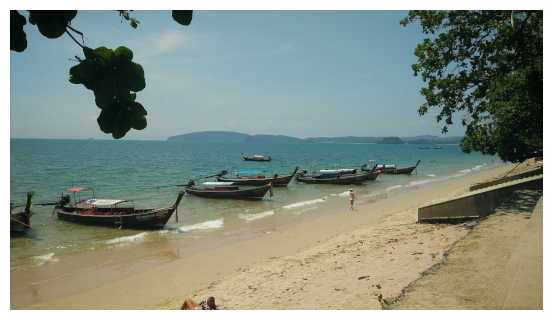

In [3]:
show_image_from_array(image)

By default, `show_image_from_array()` visualizes the full image by combining all RGB channels. However, the method also allows to specify the color channel &mdash; here `0` (red), `1` (green), or `2` (blue) to visualize only the respective channel. As shown below, by setting the argument `channel=0`, we can look at the red color channel only.

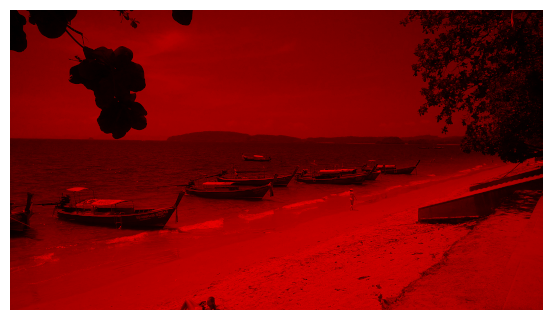

In [4]:
show_image_from_array(image, channel=0)

Setting `channel=1` gives us the green color channel.

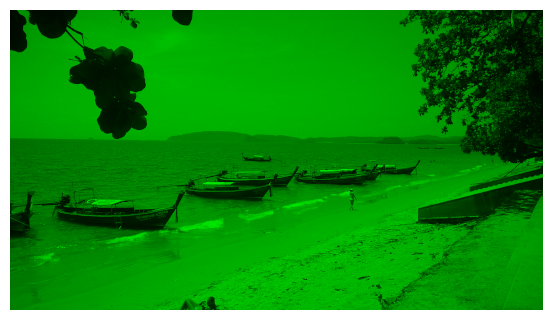

In [5]:
show_image_from_array(image, channel=1)

And lastly, with `channel=2`, we get the blue color channel.

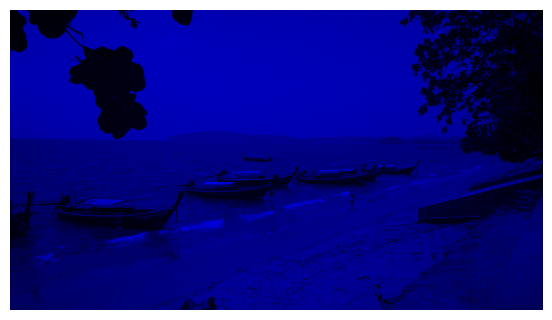

In [6]:
show_image_from_array(image, channel=2)

Although humans can often interpret an image immediately by simply looking at it, a computer does not perceive its meaning directly. In digital form, an image is represented as a multidimensional array of numerical values, such as pixel intensities or RGB channel values. These numbers describe measurable properties of the image, but they do not inherently indicate that a particular region represents a person, a tree, or a boat. 

To better appreciate this, the code cell below prints the actually values of top-left $20\times 30$ pixels area of the red color channels. Lower values indicate darker a darker red; higher values indicate a brighter red. Thus, if you look closely, you can make out the leaf in the very top-left corner (which is very dark because it is in the shadow), the brighter area to the left showing bits of the sky, and the further the next dark area (again, representing a leaf in the shadow).

In [7]:
draw_matrix(image[:20,:30,0])

<IPython.core.display.Latex object>

As such, images differ fundamentally from structured data such as tabular data because each column in a table usually has an explicit meaning, such as age, income, or temperature. In contrast, the individual values in an image array typically represent pixel intensities or color components and have little semantic meaning on their own. Meaning emerges only from the spatial arrangement and relationships among many pixels. A small group of neighboring pixels may form an edge, while larger patterns may represent textures, shapes, or complete objects.

This makes image analysis and machine learning particularly challenging. Images are often high-dimensional, contain strong spatial dependencies, and can vary in position, scale, lighting, orientation, and background even when they depict the same object. Traditional methods that treat each value as an independent feature are therefore usually ineffective. Successful image-based models must learn meaningful visual features and account for the spatial structure of the data, which requires specialized techniques such as convolutional neural networks.

### Limitations of Fully Connected Networks

To better understand the challenges that come with working with images for machine learning tasks, it is useful to see where and why basic neural networks fail. A basic neural network typically consists of several fully connected, or dense, layers. In each layer, every neuron receives input from all neurons in the previous layer, computes a weighted sum, adds a bias, and passes the result through a nonlinear activation function. These activation functions are essential because they allow the network to learn complex, non-linear relationships; without them, multiple layers would effectively behave like a single linear transformation. By stacking such layers, the network can gradually transform its inputs into increasingly useful representations for a given task. These basic networks are also called Multilayer Perceptrons (MLPs).

Basic neural networks generally perform very well on supervised learning tasks involving structured, numerical data, such as classification and regression. When the input can be represented as a fixed-size feature vector (for example, customer attributes, financial measurements, or sensor readings) fully connected layers can effectively learn complex relationships between the features. They are especially suitable when the data does not have strong spatial or sequential structure that would require specialized architectures such as CNNs.

As a "counterexample" consider the task recognizing handwritten digits. Recognizing handwritten digits is a multiclass classification task in which a model receives a, say, $28\times 28$ grayscale image and predicts which digit from $0$ to $9$ it represents. This means that each image contains $784$ pixel-intensity values, typically ranging from $0$ for black to $255$ for white. The figure below shows a few examples of handwritten digits together with their ground-truth labels from a public available [dataset](https://en.wikipedia.org/wiki/MNIST_database).

<img src="images/illustrations/cnn/cnn-motivation-handwritten-digits.png" style="max-width:600px;margin:auto;width:100%" alt="CNN Motivation - Handwritten Digits">

<br />

In another notebook we show that we can train a basic $2$-layer neural network on this task and achieve an F1 score of $96\%$ on the test set. At a first glance, this might seem to indicate that basic neural networks are suitable for image classification tasks. However, this is quite misleading since handwritten digit classification is a very constraint, and in some sense, very simple task in the context of image analysis. In fact, there are various reasons that makes this task rather straightforward, summarized by the table below.

| Aspect                              | Why basic neural networks do well                                                                                   | Why it does not generalize to other image tasks         |
| ----------------------------------- | --------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Small image size                    | A $28\times 28$ image contains only $784$ input values, making a fully connected network computationally manageable.            | Real-world images are often much larger, producing millions of input values and many more parameters.                                                  |
| Grayscale representation            | A single intensity value per pixel simplifies the input and reduces the number of features.                           | General images often contain multiple color channels and richer visual information.                                                                    |
| Fixed image dimensions              | Every image can be directly converted into the same fixed-size input vector.                                          | General image datasets may contain different resolutions, aspect ratios, or image formats.                                                             |
| Centered and aligned digits         | Similar parts of the digits tend to appear in roughly corresponding locations, making pixel-based learning effective. | Objects in general images can appear at different positions, scales, and orientations.                                                                 |
| Simple background                   | The digit is usually separated clearly from a largely uniform background.                                             | Real images may contain clutter, shadows, textures, and complex backgrounds.                                                                           |
| Limited number of classes           | The model only needs to distinguish between ten well-defined categories.                                              | General image tasks may involve thousands of classes or visually similar categories.                                                                   |
| Constrained visual structure        | Digits are composed mainly of simple strokes, curves, and edges.                                                      | Real-world objects can have complex shapes, textures, parts, and interactions.                                                                         |
| Relatively low variation            | Although handwriting differs, the possible forms of each digit remain fairly limited.                                 | General images exhibit much greater variation in appearance, lighting, viewpoint, and context.                                                         |
| Limited need for spatial invariance | Small positional differences may still be handled by a sufficiently trained fully connected network.                  | General image analysis usually requires strong translation, scale, and rotation robustness, which convolutional architectures handle more efficiently. |


In short, the images of handwritten images are small, standardized, and contain relatively simple visual patterns. This includes that even an individual pixel can provide useful information for recognizing a handwritten digit, especially when its location is considered. For example, a bright pixel near the center of a digit image may indicate that the center is empty, which is characteristic of the enclosed region of a handwritten $0$. This makes these types of images essentially structured data &mdash; and therefore suitable for basic neural networks.

However, fully connected neural networks treat an image as a **flat list of independent input values**. Flattening an image discards its natural two-dimensional structure and makes it harder for the network to recognize that nearby pixels form meaningful patterns such as edges, textures, and shapes. In addition, fully connected layers require a **separate connection between every input pixel and every neuron**, leading to a very large number of parameters for realistic image sizes. These limitations make basic networks inefficient, prone to overfitting, and less robust to changes in an object's position, scale, or orientation. They are therefore poorly suited not only to image classification, but also to object detection and segmentation, where the model must preserve spatial information and identify where objects or regions occur.

### What we Want &mdash; A "Wishlist" for Computer Vision

#### Preservation of Spatial Structure

Images are intrinsically two-dimensional data objects governed by spatial coherence. Unlike tabular data &mdash; where each feature column represents an independent variable &mdash; an image's meaning relies entirely on the spatial relationships between adjacent pixels. The pixels are arranged in rows and columns, and nearby pixels are often related because they may belong to the same edge, texture, contour, or object part. These spatial relationships provide important information for interpreting an image: a group of neighboring pixels can form a meaningful visual pattern that would not be apparent when considering each pixel independently.

Basic neural networks such as multilayer perceptrons (MLPs), however, generally expect their input as a one-dimensional vector. An image must therefore be flattened before it can be processed. Although flattening preserves the pixel values, it removes their explicit two-dimensional arrangement. Pixels that are neighbors in the original image are not necessarily neighbors in the flattened vector, while pixels that become adjacent in the vector may be far apart in the image. The animation below illustrates the processes of flatting using a simple image containing a handwritten digit. While horizontally adjacent pixels may remain relatively close in the resulting vector &mdash; since we flatten row by row in this example &mdash; vertically and diagonally adjacent pixels are forced apart by entire row lengths.

<video src="images/animations/cnn/cnn-motivation-flatten-image-example.mp4" controls="" style="margin:auto;max-width:800px;width:100%" />

Also, keep in mind that this is only a single-channel image. In the case of RGB images with three color channels, we would even further break up related pixel values and get an output vector three times the size as for single-channel images. As a result, basic neural network architectures such as MLPs do not naturally know which pixels are spatially related or that the same local pattern should be recognized wherever it appears. It can potentially learn these relationships from sufficient training data, but it must discover them indirectly and often inefficiently. We therefore need network architectures that preserve and and, in fact, exploit the spatial structure of images.

#### Support of Translation Equivariance & Invariance

One of the main arguments that basic neural networks may actually perform well for recognizing handwritten images was that the images had a (more or less) fixed structure, where each digit was centered and aligned &mdash; in other words, similar parts of an image where likely have the same location in the image. Because of this "artificial" consistency, structural components of the same digit (e.g., the horizontal top stroke of a `5` or the central loop of an `8`) consistently align with the exact same pixel coordinates across different samples. When the image is flattened into a 1D vector, these shared features activate the exact same indices in the input layer, allowing the MLP to easily map these reliable neuron activation patterns to the correct output class.

This situation changes when the digits are **shifted, rotated, or otherwise poorly aligned**. If the same digit appears in different locations, its strokes and other visual parts will activate different input neurons in the flattened representation. Two images of the same digit can therefore produce substantially different input patterns, even though they should receive the same classification. An MLP must learn separate responses for these different positions or rely on seeing many variations during training, making the task more difficult. The animation below shows a simple example of moving a handwritten `5` from left to right, and how this effects the flattened vector and therefore at the activations of input neurons of an MLP.

<video src="images/animations/cnn/cnn-motivation-translation-example.mp4" controls="" style="margin:auto;max-width:800px;width:100%" />

It is easy to see that the problem would quickly become even more pronounced for larger images where the digit can also change its location horizontally and to a much larger degree.

This positional rigidity highlights the core failure mode of standard neural networks: they are fundamentally incapable of decoupling *what* an object is from *where* it is located. To recognize an unaligned digit using a standard MLP, the network would either need to be trained on redundant examples of every digit at every possible pixel coordinate, or maintain duplicate sets of weights across the entire input space. This inability to naturally generalize across spatial shifts demonstrates why basic MLPs fall short for real-world visual recognition, establishing a clear need for architectures capable of learning **translation-invariant representations**.

#### Learning Compositional Structures

Objects of interest in images, such as faces, animals, and traffic signs, are typically complex structures rather than indivisible patterns. They are composed of simpler shapes and parts: a face contains eyes, a nose, a mouth, and contours; an animal consists of body parts and characteristic shapes; and a sign may be formed from geometric regions and symbols. These shapes themselves are built from even more basic visual features, such as edges, corners, and changes in color or intensity.

This suggests that a useful neural network should learn visual representations hierarchically. Lower layers can identify low-level features such as horizontal and vertical edges. Intermediate layers can combine these features into motifs, textures, and simple shapes, while deeper layers can combine those patterns into meaningful object parts and complete objects. Such a progression allows the network to build complex concepts from simpler components instead of having to learn every object directly from raw pixel values.

#### Limiting Parameter Explosion

Images are generally high-dimensional data objects because every pixel can be viewed as a separate input feature. A basic neural network typically connects these pixel values to subsequent neurons using individual weights. For example, a modest $1024 \times 1024$ RGB image yields over $3$ million input features (we have $3$ color channels!); connecting this input to a hidden layer of just $1,000$ neurons requires over $3$ billion parameters in the first layer alone. Consequently, increasing the image resolution increases the number of input features and can cause the number of learnable parameters to grow rapidly. For large or high-resolution images, this can lead to substantial memory and computational requirements.

To make computer vision scalable, we favor network architectures where the number of learnable parameters does not directly depend on the spatial size of the input images. Ideally, a model should reuse a compact, fixed set of weights to extract meaningful visual patterns regardless of whether the input is a small thumbnail or a high-resolution photograph. Decoupling model capacity from image resolution allows networks to remain computationally efficient, parameter-wise lean, and capable of processing inputs of varying spatial dimensions without suffering from an explosion in model size.

---

## Image Convolution

The idea of image convolution predates neural networks by several decades. It originated as a general image-processing technique in which a small matrix or multidimensional tensor, called a kernel or filter, is moved across an image to compute a new value for each pixel based on its local neighborhood. By choosing different kernel values, convolution can smooth images, sharpen details, detect edges, reduce noise, or highlight particular visual patterns. These operations were widely used in traditional computer vision and digital image processing long before convolutional neural networks were introduced.

Before learning about CNNs, it is useful to first understand how basic image convolution works as a traditional image-processing technique. This provides an intuitive foundation for seeing how a kernel moves across an image and combines neighboring pixel values to detect or enhance visual patterns. Once this process is clear, it becomes much easier to understand the transition from using fixed, predefined kernels to using trainable kernels that are learned automatically from data in a CNN.

### Image Filters & 2D Convolutions

Image convolution, or two-dimensional convolution, is a technique for processing images using a small matrix (more generally a multidimensional tensor) called a kernel or filter. The kernel is moved across the image so that, at each position, it covers a local image patch with the same dimensions as the kernel. In the most basic case, the kernel moves one pixel at a time, visiting each possible patch in the image.

For every patch, the corresponding image and kernel values are multiplied pairwise and then added together. This sum of products becomes a single value in the output image, indicating how strongly the local patch matches the pattern represented by the kernel. By choosing different kernel values, convolution can be used to detect edges, sharpen details, blur regions, or highlight other visual structures.

The animation below shows to idea of image convolution assuming a $56$ image (i.e., an image with a height and width of $5$ and $6$ pixels) and $33$ kernels. As we will see later in an example, this kernel can be used to sharpen an image. The yellow rectangle moving over the image highlights the current patch that is used to compute the respective output values. Given the size of the image and the kernel, the output is of size $34$. Lastly, the animation also shows the actual calculation being performed to get the output for the current patch.

<video src="images/animations/cnn/cnn-image-convolution-basic-concept.mp4" controls="" style="margin:auto;max-width:800px;width:100%" />

Convolution kernels do not have to be square or restricted to a size of $3 \times 3$. Rectangular kernels, such as $3 \times 5$, are also possible, and even-sized kernels can be used. However, square kernels, such as $3 \times 3$ or $5 \times 5$, are common because they treat horizontal and vertical directions uniformly and simplify the architecture and implementation. They also provide a clearly defined center pixel. This makes it easier to align the kernel with the image and apply symmetric padding (covered later), ensuring that the output remains spatially aligned with the input &mdash; notice that right now the output is smaller than the input.

### Basic Implementation & Examples

Basic image convolution is conceptually simple to implement because it consists of a small number of repeated operations. A kernel matrix is moved systematically across the image, typically one pixel at a time, and at each position it is aligned with a local image patch of the same size. The output value for that position is then computed as the sum of the products between corresponding kernel and image values. Repeating this procedure for all valid positions produces the filtered output image.

This regular structure also makes image convolution well suited to implementation with nested loops: outer loops iterate over the kernel's position in the image, while inner loops compute the weighted sum for the current patch. Although modern implementations use highly optimized libraries and hardware acceleration, the underlying algorithm remains straightforward enough to implement from scratch. This makes basic convolution an ideal starting point for understanding how fixed image-processing filters work before extending the idea to learned kernels in convolutional neural networks.

To this end, the method `filter_image()` implements basic image convolution. It takes in a NumPy array representing an RGB image (see above) and applies the given kernel matrix by implementing the nested loop moving the kernel across all corresponding patches in the image. Apart from this main functionality some additional implementation details are worth mentioning:

* **Casting to floating-point type.** We cast the UINT8 (unsigned integer) image array a floating-point array for two main reasons: (a) to **avoid integer overflow** since sum of products of pixel and kernel values can easily exceed the limited range of UINT8 ($0$ to $255$), and (b) to **preserve fractional results** since kernels often contain floating-point values, such as `0.5`, `−1.2`, or `1/9`.

* **Determining the output size.** We already saw that the size of the kernel determines the size of output. We therefore need to compute the output size depending on the size of the image and the kernel.

* **Multichannel images.** Images format such as RGB represent a single image using multiple $2$-dimensional arrays, each denoted as channel (e.g., $3$ channels in case of RGB). Basic image convolution applies the same kernel independently to all channels, yielding an output for each channel &mdash; which then combined represent the output image. Thus, we need another loop that iterates over each channel.

* **Clipping and casting out.** To return an output the represents a valid RGB image, i.e., $3$-dimensional UINT8 image array, we need to (a) clip all values outside the range of $0..255$ to both boundaries, and (b) cast the image array from its temporary floating-point representation back to UINT8.

In [8]:
def filter_image(image_array, kernel):
    # Convert integer inputs to floating point before multiplication
    image_array = image_array.astype(np.float32)
    kernel = np.asarray(kernel, dtype=np.float32)

    # Input dimensions
    H, W, C = image_array.shape
    kH, kW = kernel.shape
    
    # Output dimensions
    H_out, W_out, C_out = (H - kH), (W - kW), C

    # Define output array (i.e., image) and initialize to 0
    output = np.zeros((H_out, W_out, C_out))
    
    # Perform convolution
    for i in range(H_out):
        for j in range(W_out):
            # Define the current slice
            h_start, h_end = i, (i + kH)
            w_start, w_end = j, (j + kW)
            for c in range(C_out):
                # Extract image patch of current channel
                patch = image_array[h_start:h_end, w_start:w_end, c]
                # Perform convolution
                output[i, j, c] = np.sum(patch * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)

To test the method `filter_image()`, we can apply it to our example image of the beach scenery together with different kernels. Again, although not a principle limitation, we consider only $33$ kernels in the following example. We start with a kernel where are values are `1/9`, i.e., where all values are the same and they sum up to $1$. Considering the convolution computes the sum of the products between the kernel value and the corresponding pixel values in the current image patch, it is easy to see that the output value is simply the average of all pixel values in that patch. Visually this means that we add **blur** to the image.

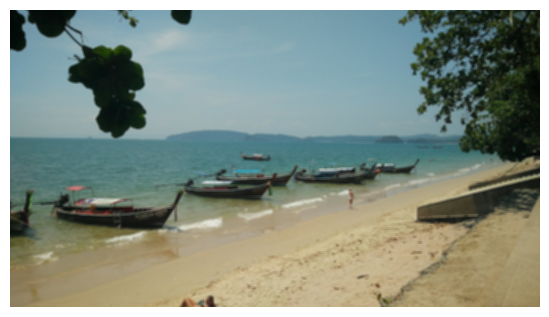

In [9]:
blur_kernel = np.array([[1/9, 1/9, 1/9], 
                        [1/9, 1/9, 1/9],
                        [1/9, 1/9, 1/9]])

output = filter_image(image, blur_kernel)

show_image_from_array(output)

The next kernel we consider is commonly used for sharpening an image. Its intuition is to strongly preserve the central pixel while subtracting the values of its neighboring pixels. In smooth regions, the center and neighbors have similar values, so the result changes little because the kernel weights sum to $1$. At edges, however, the center differs substantially from its surroundings, so the subtraction increases this difference and makes the edge appear sharper. Thus, the kernel enhances local intensity changes while largely preserving uniform areas.

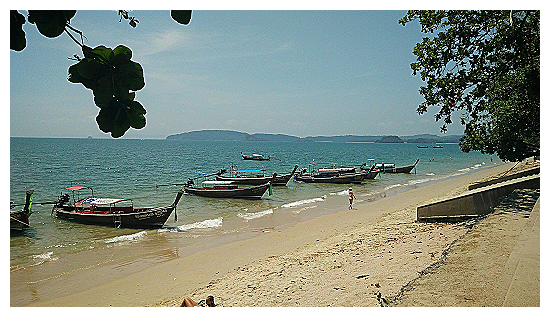

In [10]:
sharpen_kernel = np.array([[0, -1, 0],
                           [-1, 5,-1],
                           [0, -1, 0]])

output = filter_image(image, sharpen_kernel)

show_image_from_array(output)

For the last examples, we consider various kernels used for edge detection. The first one focuses on vertical edges. It subtracts pixel values on the left from those on the right. In a uniform region, these values are similar and the result is close to zero. At a vertical edge, however, the intensity changes sharply from left to right, producing a large positive or negative response. The sign indicates the direction of the intensity change, while the magnitude indicates how strong the edge is.

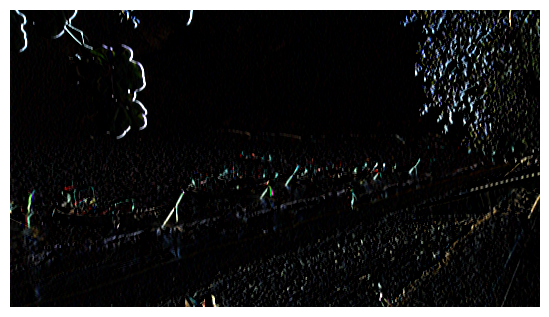

In [11]:
vedge_kernel = np.array([[-1, 0, 1], 
                         [-1, 0, 1],
                         [-1, 0, 1]])

output = filter_image(image, vedge_kernel)

show_image_from_array(output)

By rotating the previous kernel, we can focus on detecting horizontal edges. The underlying intuition which parts in an image get "ignored" (i.e., the output value for that path is close ti $0$) and which get highlighted is exactly the same, just with respect to the horizontal change in intensity.

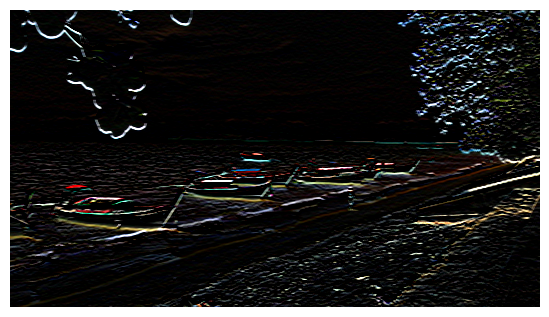

In [12]:
hedge_kernel = np.array([[-1, -1, -1], 
                         [0 ,  0,  0],
                         [ 1,  1,  1]])

output = filter_image(image, hedge_kernel)

show_image_from_array(output)

We can also combine vertical and horizontal edge detection using the so-called Laplacian edge-detection kernel which compares the center pixel with all eight surrounding pixels. Again, in a uniform region, the center is similar to its neighbors, so the result is close to zero. Near an edge or other sharp intensity change, the center differs strongly from its surroundings, producing a large positive or negative response. Unlike directional kernels, it detects edges in all directions, but it is also more sensitive to noise.

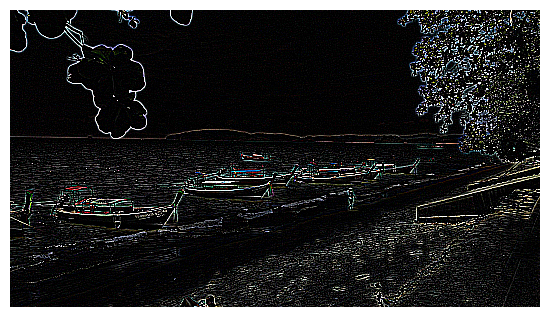

In [13]:
# Laplacian edge detection kernel
laplacian_kernel = np.array([[-1, -1, -1], 
                             [-1,  8, -1],
                             [-1, -1, -1]])

output = filter_image(image, laplacian_kernel)

show_image_from_array(output)

To sum up, basic image convolution applies predefined kernels to an image to modify it, for example by smoothing, sharpening, or detecting edges. The kernel values determine which visual patterns are emphasized or suppressed. Convolutional neural networks turned this idea upside down: instead of manually designing the kernels, CNNs learn them automatically from data. During training, the network discovers which filters are useful for the task. Let's explore how this works next.

---

## Convolution as Neural Network Layer

In this section, we first focus on an individual convolutional layer. We will see and discuss later that CNNs typically consist of several such convolutional layers, which requires additional considerations.


### Basic Setup

Adopting image convolution as a neural network layer involves performing a very similar operation: a small kernel is moved across an image, and each patch is replaced by a weighted sum. However, instead of using a predefined kernel (e.g., to blur/sharpen images or to detect edges), in a convolutional layer, the **kernel values are learnable parameters** of the network that gets updated based on some learning objective (i.e., image classification, image segmentation, object detection). This fundamental change in the use of kernels entails some other importance differences (compared to basic image convolution):

* **Multiple kernels.** Instead of a single kernel, a convolutional layer typically **learns many kernels together** because a single kernel can detect only one type of local pattern, such as a particular edge orientation or texture. Multiple kernels allow the layer to detect many different patterns at the same spatial location and produce a separate feature map for each one. The kernels generally learn different weights because training updates each kernel according to the patterns it is useful for detecting. Since the kernels start with different values and receive different gradients, they specialize in different features &mdash; for example, one may respond to horizontal edges, another to vertical edges, and others to color transitions or textures. 

* **Output: image vs. feature map.** The output of a convolutional layer is generally no longer an image intended for direct human interpretation. Although it often retains spatial dimensions, its values represent the strength of a learned feature at each location (e.g., the presence of a particular edge, texture, or shape). Such an output is therefore called a **feature map**. A layer with multiple kernels produces multiple feature maps, each representing a different learned feature.

* **Multichannel handling.** A convolutional filter applies a separate set of spatial weights to each input channel. For an RGB image, a $3\times 3$ filter therefore has one $3\times 3$ kernel for the red channel, one for the green channel, and one for the blue channel &mdash; thus yielding $3 \times 3 \times 3 = 27$ learnable weights. The filter computes a weighted sum for each channel and then adds these three results to produce a single value at each spatial location. Consequently, **one filter produces one feature map** that combines information from all RGB channels.

* **Combining layers.** CNNs typically stack multiple convolutional layers so that the network can learn increasingly complex features. The first layer may detect simple patterns such as edges or color transitions, while later layers combine these responses to recognize textures, shapes, and object parts &mdash; discussed in more detail later. Consequently, the input to a deeper convolutional layer is usually no longer a raw image. Instead, it is a collection of feature maps produced by the previous layer, often after applying operations such as a bias, activation function, normalization, or pooling. Each new layer processes and combines these feature maps to build a richer representation of the original image.

We can there generalize the idea of image convolution by applying some kernel $\mathbf{W}$ containing the kernel weights $w$ to some input $\mathbf{X}$ containing the input values $x$ to get some output $\mathbf{}$, with $y$ being the individual result of the convolution calculation. The animation below illustrates this idea for a single-channel input. This means that input $\mathbf{X}$, kernel $\mathbf{W}$, and output $\mathbf{Y}$ are $2$-dimensional matrices. The fundamental calculation of the individual convolution values remains exactly as we have seen in the example of a basic image convolution before.

<video src="images/animations/cnn/cnn-image-convolution-layer-single-channel.mp4" controls="" style="margin:auto;max-width:800px;width:100%" />

As just mentioned, for multichannel images (e.g., RGB images) the convolution calculation differs from the one for basic image convolutions. Here, the kernel is now also a $3$-dimensional tensor with a kernel height $k_h$, a kernel width $h_w$, and the number of channels $c$. The $c$-th $2$-dimensional tensor of size $k_h\times h_w$ is applied to the $c$-th channel of the input. This gives $c$ individual values that are summed up to get the final values for a value in output $\mathbf{Y}$. We therefore now need three subscripts to identify a single pixel values $x_{i,j,c}$ and kernel weight $w_{m,n,c}$, where $(i,j)$ and $(m,n)$ refer to the spatial positions of the values in $\mathbf{X}$ and $\mathbf{W}$.

With this, we can compute the output $y_{i,j}$ by summing up the convolutions with respect to all (here: $3$) channels as shown below. In this expression, the three sums reflect the triple nested `for`-loop in our method `filter_image()`. Note that we also now added the bias $b$ to allow the filter to shift its response independently of the weighted input sum. Without a bias, the filter's output would be forced to zero whenever the weighted input sum is zero. The bias provides an adjustable baseline, making it easier for the filter to activate when a learned feature is present.

$$\large
y_{i,j} = b + \sum_{m=0}^{k_h-1}\sum_{n=0}^{k_w-1}\sum_{c=0}^{2}w_{m,n,c}\,x_{i+m,j+n,c}
$$

The animation below visualizes the performed convolution for a $3$-channel input. However, the involved operations are equivalent for more or less input channels &mdash; recall that an early convolutional layer may have, say, $32$ filters resulting in $32$ outputs, i.e., feature maps. This output may then serve as $32$-channel input to a subsequent convolutional layer.

<video src="images/animations/cnn/cnn-image-convolution-layer-multichannel.mp4" controls="" style="margin:auto;max-width:800px;width:100%" />

In short, computing one value $y_{i,j}$ in a feature map involves multiplying the corresponding input values by the kernel weights and adding the results &mdash; across all channels! &mdash; along with a bias: This is a weighted sum, or affine transformation, and is therefore linear with respect to the input apart from the bias term. The convolution itself does not introduce nonlinearity; nonlinear activation functions such as $\text{ReLU}$ are typically applied afterward.

### Common Convolution Parameters

The definitions and animations we have seen so far refer to the most basic case of convolution, where we convolve over the original image by moving a kernel across the image pixel by pixel. However, the core idea of convolution is not limited to this basic setup. The three most common methods to change the exact underlying operations required for the convolution are: add **padding**, change the **stride**, and add **dilation**. In the following, we briefly outline and illustrate their effects.

#### Padding

We saw that, by default, the size of output $\mathbf{Y}$ is smaller than the size of input $\mathbf{}$. However, keeping feature maps the same spatial size as their inputs makes it easier to stack multiple convolutional layers without rapidly shrinking the representation. It also preserves the spatial location of features, which is important for tasks such as image segmentation and object detection. We can achieve this using **padding** (i.e., artificial pixels) around the input, often with zeros. For example, combining a $3\times3$ kernel with a $1$-pixel padded input results in an output $\mathbf{Y}$ with the same height and width as the input $\mathbf{X}$. This is commonly called **same padding** and visualized in the animation below assuming a single-channel input for simplicity.

<video src="images/animations/cnn/cnn-image-convolution-layer-padding.mp4" controls="" style="margin:auto;max-width:800px;width:100%" />

More generally, we can compute the size of the output, i.e., its height $H_{\text{out}}$ and width $W_{\text{out}}$ using the following expressions:

$$
\begin{align}
\large H_{\text{out}}\ &\large= H + 2p - k_h + 1\\[0.75em]
\large W_{\text{out}}\ &\large= W + 2p - k_w + 1
\end{align}
$$

where $p$ is the padding applied to each side, and $k_h$ and $k_w$ are the height and the width of the kernel.

Of course, padding introduces artificial values around the image, which do not represent real visual content. Consequently, filters near the borders process partly artificial patches, so their outputs may be less reliable and can contain edge artifacts. Padding also increases the computational cost because the convolution processes additional values. In deep networks, repeatedly padding every layer can therefore add some unnecessary computation, although the benefits of preserving spatial dimensions often outweigh this cost.

#### Stride

The **stride** refers to the amount of pixels by which we move the kernel across the input; moving the kernel pixel by pixel means using a stride of $1$. As such, a stride larger than $1$ makes the kernel move more than one pixel at a time. Its main purpose is to **downsample** the feature maps while extracting features, reducing their spatial resolution and the computational cost of subsequent layers. Naturally, increasing the stride therefore produces fewer output values and smaller feature maps.

For example, a stride of $s=2$, as shown in the animation below, roughly halves the output size.

<video src="images/animations/cnn/cnn-image-convolution-layer-stride.mp4" controls="" style="margin:auto;max-width:800px;width:100%" />

The exact output size depends on whether the height and width of the input is divisible by the stride; the exact formula for the output size is given by the following expression:

$$\large
H_{\text{out}} = \left\lfloor\frac{H+2p-k_h}{s}\right\rfloor+1
$$

with an analogous expression for the width $W_{\text{out}}$.

Using a stride larger than $1$ reduces the spatial size of feature maps, lowering memory usage and computational cost while allowing the network to progressively summarize information. The disadvantage is that skipping positions can discard fine-grained spatial details and make precise localization more difficult. This creates an important practical tradeoff when designing CNNs: larger strides make the network more efficient, but smaller strides preserve more spatial information at a higher computational cost. The appropriate choice depends on the task (for example, classification can often tolerate more downsampling than segmentation or object detection).

#### Dilation

**Dilation** enlarges the area covered by a convolutional kernel by inserting gaps between its weights. For example, a $3\times3$ kernel with dilation rate $2$ samples pixels two positions apart, giving it the receptive-field size of a $5\times5$ kernel while still using only nine weights &mdash; as visualized in the animation below. In general, the effective kernel size is:

$$
\begin{align}
\large k_{\text{effective}}\ &\large= k + (k-1)(d-1)\\[0.75em]
&\large= d (k-1) + 1
\end{align}
$$

where $d$ is the dilation rate. Consequently, including padding and stride, the output height can be computed as:

$$\large
H_{\text{out}} = \left\lfloor \frac{H+2p-k_{\text{h/effective}}}{s} \right\rfloor+1
$$

and similarly for the width $W_{\text{out}}$. Thus, increasing the dilation rate generally produces a smaller output if the padding remains unchanged. In practice, padding is often increased accordingly so that the feature map retains the same spatial size, just as with "same" convolutions.

<video src="images/animations/cnn/cnn-image-convolution-layer-dilation.mp4" controls="" style="margin:auto;max-width:800px;width:100%" />

The intuition is that dilation allows a CNN to capture a broader spatial context without increasing the number of learnable parameters or reducing the feature-map resolution through a larger stride. This is useful when features depend on information spread over a larger area, such as in segmentation. However, large dilation rates sample the input more sparsely, which can cause the layer to miss fine details or create gridding artifacts.

### Example Implementation

Now that we conceptually understand how a convolutional layer works, let's actually look at some example code to better understand the implementation of such layers. We do this in two ways. First, we focus on the core operation involved by generalizing the example code for basic image convolution. We then treat convolution as a proper layer, meaning first and foremost that the kernels become learnable parameters (instead of predefined values).


#### Core Operation

To better understand the difference compared to basic image convolution, let's first extend the method `filter_image()` to incorporate all changes and additional parameters; see the implementation of method `filter_input()` in the code cell below. The major changes refer to:

* **Convolution parameters.** The method now supports various values for padding, stride, and dilation. This includes the computation of the output size using the expressions to get those values as defined above, as well as the extraction of the current patch &mdash; particularly the effect of dilation on the path. For the padding, we simply use the NumPy method [`np.pad()`](https://numpy.org/doc/stable/reference/generated/numpy.pad.html).

* **Output format.** Since the filter of a convolutional layer combines the outputs for all channels, the output array no longer features a channel dimension. This also requires changing the nested loops where the result for each channel is added to the result for a patch.

**Important:** This implementation assumes that we always perform the same padding, stride, and dilation for both the height and with dimension (we also use a fixed padding value of $0$). In principle, all three parameters may differ for height and width. Extending the method `filter_input()` to support this is a very straightforward task. However, it does add several lines of (very similar) code, and the focus here is in simplicity and readability for understanding.

In [14]:
def filter_input(image_array, kernel, padding=0, stride=1, dilation=1):
    # Convert integer inputs to floating point before multiplication
    image_array = image_array.astype(np.float32)
    kernel = np.asarray(kernel, dtype=np.float32)

    # Input dimensions
    H, W, C = image_array.shape
    kH, kW = kernel.shape

    # Effective kernel size after dilation
    kH_eff = dilation * (kH - 1) + 1
    kW_eff = dilation * (kW - 1) + 1

    # Add zero padding around height and width dimension; ignore channel dimension
    padded_image = np.pad(image_array, pad_width=((padding, padding), (padding, padding), (0, 0)), mode="constant", constant_values=0)

    # Compute output dimensions
    H_out = (H + 2 * padding - kH_eff) // stride + 1
    W_out = (W + 2 * padding - kW_eff) // stride + 1

    # Define output array and initialize to 0 (notive the lack of channel dimension)
    output = np.zeros((H_out, W_out), dtype=np.float32)

    # Apply the kernel independently to each channel
    for i in range(H_out):
        for j in range(W_out):
            h_start = i * stride
            w_start = j * stride
            # Sum up results for current patch across all channels
            for c in range(C):
                patch = padded_image[
                    h_start:h_start + kH_eff:dilation,
                    w_start:w_start + kW_eff:dilation,
                    c
                ]
                # Add channel result to patch
                output[i, j] += np.sum(patch * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)

For testing, we can apply the method `filter_input()` to our example image. In the example below, we use the method together with the Laplacian kernel for edge detection again, but now using values for padding, stride, and dilation different from the basic image convolution. For printing the result, we first only show the shape of the output.

In [15]:
output = filter_input(image, sharpen_kernel, padding=10, stride=2, dilation=2)

print(f"Shape of output: {output.shape}")

Shape of output: (158, 275)


Notice that the output now only has two dimensions since we sum up the convolution results for each channel (for a given patch). The height and width of the output is now "slightly above half" the size of the input image. This is mainly because (a) we add a lot of padding (10 pixels, by default), but (b) also use a stride of $2$ which roughly halves the output; higher dilation values also decrease the size of the output but not the multiplicative manner.

**Important:** Recall that the output is strictly speaking no longer considered an image for human interpretation but a feature map. It just so happens that the kernel weights represent the Laplacian edge detection kernel &mdash; and the input is indeed an image instead of the feature map from a previous convolution layer! In practice, the kernel weights can be arbitrary values learned during training. As such, for this example, we can use our auxiliary method `show_image_from_array()` to visualize the output since with this kernel, the feature map will kind of reflect the input image &mdash; but again, it is no longer a valid RGB image!

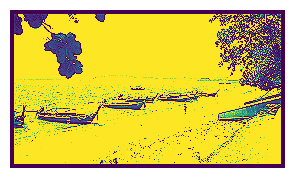

In [16]:
show_image_from_array(output)

Despite not being an RGB image but strictly speaking a feature map, given the well-defined kernel, we can still make out content of the original input image. We can also see the effect of the $0$-padding resulting in a "frame" around the image. And of course, because of the stride of $2$, the image is now only roughly half the size as the original image. The effect of different delation values is much more difficult to visually observe.

#### Neural Network Layer

The method `filter_input()` represents a minimal example that applies the convolution operation to an input for a given kernel. However, to use convolution as part of a neural network, we need to implement it as a proper network layer. To this end, the custom `Conv2d` class mimics the basic interface and behavior of PyTorch’s [`nn.Conv2d`] while relying exclusively on NumPy. This class is not intended for practical use: it is deliberately simplified, lacks an implemented backward pass, and is much less efficient than optimized deep-learning libraries. Its purpose is purely illustrative and educational, helping clarify the fundamental mechanics of a convolutional layer without relying on PyTorch or automatic differentiation.

* **Argument names.** The class uses the same argument names such `in_channels`, `out_channels`, `kernel_size`, `stride`, `padding`, `dilation`, and `bias` as the `nn.Conv2d` class of PyTorch.

* **Kernels as learnable parameters.** The class attributes `self.weight` represent the set of all kernels. The number of kernels is determined by the number of output channels `out_channels`. The weights across all kernels are initialized using uses a He/Kaiming-style random initialization, where the weights are sampled from a zero-centered normal distribution with standard deviation $\sqrt{2/n_{in}}$ where $n_{\text{in}} = \text{in\_channels} \times \text{kernel\_height} \times \text{kernel\_width}$.

* **Batched inputs.** Instead of processing single images, the class expects batches of images as input for the `forward()` method. This means that the input has now shape of $(B, C, H, W)$, where $B$ is the batch size (i.e., number of images), $C$ is the number of channels for each image, and $H$/$W$ is the height/weight of each image. Notice that the number of channels comes here before the height and width. This is in line with the input expected by `nn.Conv2d`.

* **Convolution parameters.** Like for method `filter_input`, we assume that the padding, stride, and dilation is the same for both height and width. We also assume that we have only square kernels. Again, this is not a principle limitation but it allows for a simpler and more concise code which is much more useful here.

* **Additional complexity.** Since the class performs convolution over *multiple images* using *multiple kernels*, the nested loops in the `forward()` that implements the convolution operations are now more involved compared to the `filter_input()` implementation. It uses various indexing and slicing strategies to implement the convolution for all images with respect to all kernels efficiently. However, the core operation to compute the convolution values is exactly the same.

Again, keep in mind that this implementation only includes the forward pass implemented by the `forward()` method. For updating the kernel weights during some network training, we would also need to implement the `backward()` method to receive the upstream gradients, compute the local gradients to update all weight, and compute the downstream gradient to pass it on as part of the whole backpropagation step. However, the consideration of the backward pass is beyond the scope of this introductory notebook and requires a more focused discussion.

In [17]:
class Conv2d:
    
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, bias=True):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.dilation = dilation

        # uses a He/Kaiming-style random initialization
        self.weight = np.random.randn(
            out_channels,
            in_channels,
            kernel_size,
            kernel_size,
        ) * np.sqrt(
            2.0 / (in_channels * kernel_size * kernel_size)
        )

        self.bias = np.zeros(out_channels) if bias else None

    
    def forward(self, x):
        # Get batch size (B), number of channels (C), and heigh (H) and width (W) of images
        B, C, H, W = x.shape

        kernel_size = self.kernel_size
        stride = self.stride
        padding = self.padding
        dilation = self.dilation

        # Calculate effective kernel size depending in dilation values
        k_effective = (dilation * (kernel_size - 1) + 1)

        # Pad all input images by extending height/width dimension bu 0
        x_padded = np.pad(x, ((0, 0), (0, 0), (padding, padding), (padding, padding)), mode="constant")

        # Compute output dimensions
        H_out = (H + 2 * padding - k_effective) // stride + 1
        W_out = (W + 2 * padding - k_effective) // stride + 1
    
        # Define output array and initialize to 0 (notive the lack of channel dimension)
        output = np.zeros((B, self.out_channels, H_out, W_out), dtype=np.float32)

        # Perform convolution operation
        for n in range(B):
            for out_row in range(H_out):
                input_row = out_row * stride

                for out_col in range(W_out):
                    input_col = out_col * stride

                    patch = x_padded[
                        n,
                        :,
                        input_row:input_row + k_effective:dilation,
                        input_col:input_col + k_effective:dilation,
                    ]

                    output[n, :, out_row, out_col] = np.sum(
                        self.weight * patch[None, :, :, :],
                        axis=(1, 2, 3),
                    )

        # Add bias term if available
        if self.bias is not None:
            output += self.bias[None, :, None, None]

        return output

    
    def backward(self, grad_output):
        pass

To test the implementation, we first create an instance of class Conv2d. In the code cell below, by default, we assume that we have $3$ input channels &mdash; this means we can directly pass RGB images as input &mdash; and that we want to use $32$ kernels of size $3\times 3$. We also use $1$-pixel padding. Together with the $3\times 3$ kernels, this ensures that the height and width of the output will be the same as of the input.

In [18]:
conv2d_layer = Conv2d(3, 32, 3, padding=1)

Before we can pass our example image to the layer, recall that the shape of the image is $(H, W, C)$ but the layer expects the input to be of shape $(B, C, H, W)$. We therefore have to transform the image in the correct shape by performing the following two steps:

* Transpose to 3D image array so that be bring the last dimension (e.g., the channels) to the front and make it the first dimension; we can use the [`np.transpose()`](https://numpy.org/doc/stable/reference/generated/numpy.transpose.html) for that
* Add a new dimension representing the batch dimensions using the [`np.expand_dims`](https://numpy.org/doc/stable/reference/generated/numpy.expand_dims.html) method

The code cell below performs both these steps and prints the shapes of the initial array (the orginal image), of the array after the transpose, and after adding the batch dimension.

In [19]:
print(f"Shape of original image:   {image.shape}")

image_transposed = np.transpose(image, (2, 0, 1))
print(f"Shape of transposed image: {image_transposed.shape}")

batch = np.expand_dims(image_transposed, axis=0)
print(f"Shape of image batch:      {batch.shape}")

Shape of original image:   (300, 533, 3)
Shape of transposed image: (3, 300, 533)
Shape of image batch:      (1, 3, 300, 533)


With the correct shape, we can pass the image &mdash; strictly speaking the batch which contains only our example image &mdash; to the forward method of our convolutional layer to get the output; for the moment, we only print the shape of the output.

In [20]:
output = conv2d_layer.forward(batch)

print(output.shape)

(1, 32, 300, 533)


The output shape clearly reflects that our convolutional layer contains $32$ kernels so that the output array now features $32$ channels. We already discussed that the height and the weight of each individual feature map is the same as of the input image since we used a $3\times 3$ kernel and $1$-pixel padding. Although the outputs are the $32$ feature maps, they are still 2D arrays which means we can pass it to our auxiliary method `show_image_from_array()`. The code cell below uses the method to show the very first feature map &mdash; keep in mind that the color is not correctly interpreted since the feature map is not a RGB images with three color channels.

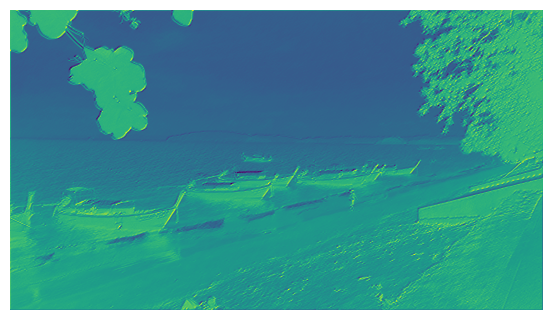

In [21]:
show_image_from_array(output[0,0,:,:])

Ignoring the color, we can see that the feature maps still very much resemble the example image. Before training, the kernels in a convolutional layer contain random weights and therefore have not yet learned to detect meaningful visual patterns. The resulting feature maps therefore may still preserve the input's spatial layout, especially when the feature-map size is unchanged, but their values generally appear noisy and do not represent useful edges, shapes, or objects. Any apparent resemblance to the original image is therefore mainly due to the preserved spatial arrangement, rather than meaningful feature extraction; training gradually adjusts the weights so that the feature maps respond to increasingly relevant visual patterns.

Lastly, to really show that our layer class performs the same operation as the method `filter_input()`, we can recreate the last example using `filter_input()` but with the layer. To ensure the same result, we naturally need to create an instance of the `Conv2d` class using the same values for the kernel size, padding, stride and dilation. But more importantly, we also need to set the weights in all kernels to weights of the kernel we used for the example above (i.e., the kernel to sharpen an image). Lastly, we need to clip the output array to the numerical range of UINT8 and then cast the array to UINT8. After that, we can again print the feature map for the first kernel.

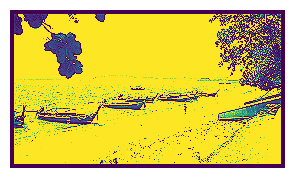

In [22]:
conv2d_layer = Conv2d(3, 32, 3, padding=10, stride=2, dilation=2, bias=False)

conv2d_layer.weight = sharpen_kernel[None, None, :, :]

output = conv2d_layer.forward(batch)

output = np.clip(output, 0, 255).astype(np.uint8)

show_image_from_array(output[0,0,:,:])

As expected, the "image" is exactly the same we saw when testing the `filter_input()` method; at least when assuming the default values for all arguments. If you have changed any argument values for testing, the outputs are of course likely to differ.

With the `Conv2d` class, we have taken the conceptual step from basic image convolution to a convolutional network layer. In traditional image processing, the kernel contains predefined values designed manually for a specific purpose, such as sharpening or edge detection. In `Conv2d`, the kernel weights (and typically the bias) are learnable parameters that can be adjusted during training to detect patterns useful for the task. Although this educational implementation is not fully complete because it omits the backward pass, it already demonstrates the central idea behind CNN layers: replacing fixed image-processing kernels with trainable filters.

---

## The CNN Architecture

A single convolutional layer is generally not sufficient to detect complex objects such as faces or animals because its kernels examine only relatively small local regions of the input. Such a layer can learn useful low-level features, such as edges, corners, color transitions, and simple textures, but these features provide only limited information about the overall structure of an object. A face, for example, is defined not by one edge or texture, but by the arrangement of multiple parts such as eyes, a nose, a mouth, and an enclosing contour.

For this reason, CNNs typically contain a series of convolutional layers. Each layer receives the feature maps produced by the previous layer and combines simpler patterns into increasingly complex representations. Earlier layers may detect edges, intermediate layers may detect motifs and object parts, and deeper layers may respond to complete shapes or objects. Stacking layers also increases the effective receptive field, allowing deeper neurons to incorporate information from larger regions of the original image. In the following, we provide an overview to the typical blueprint of a CNN architecture.

### Intermediate Layers &mdash; Pooling

Although convolutional layers are conceptually stacked, they are typically not connected as a simple sequence in which the raw output of one convolution becomes the direct input to the next. Instead, additional operations are inserted between them, most importantly a nonlinear **activation function** such as $\text{ReLU}$. Without an activation function, two consecutive convolutional layers would still represent one overall linear transformation and could effectively be replaced by a single convolutional operation. The activation function breaks this linearity and allows the network to learn complex relationships.

A second type of layer that is very commonly placed between to convolutional layers is a so-called **pooling layer**. Pooling reduces the spatial resolution of the feature maps, lowers the computational cost, increases the effective receptive field of later layers, and can make the representation less sensitive to small translations. A pooling layer summarizes information in small local regions of a feature map, reducing its spatial resolution while retaining the most important information. For example, a $2\times2$ max-pooling operation selects the largest value from each $2\times2$ region and moves across the feature map with a specified stride.

A pooling layer operates similarly to convolution in that it moves a small window across the input and processes one local patch at a time. However, pooling does not use a learnable kernel or compute a weighted sum. Instead, it applies a fixed aggregation rule to each patch, such as selecting the maximum value in max pooling or computing the average in average pooling. The resulting output therefore depends only on the values within the current patch and not on any learnable parameters or neighboring patches.

<video src="images/animations/cnn/cnn-layers-pooling-example.mp4" controls="" style="margin:auto;max-width:800px;width:100%" />

The intuition is that a strong activation indicates that a particular feature was detected somewhere in the local region. Pooling layers therefore provide several practical benefits:

* **Downsampling:** They reduce the height and width of feature maps, lowering memory usage and the computation required by later layers.
* **Larger effective context:** After downsampling, later layers can cover a larger region of the original image with relatively small kernels.
* **Local summarization:** Max or average pooling condenses the most important information from a small neighborhood.
* **Robustness to small shifts:** Pooling makes the representation less sensitive to the exact location of a feature within the pooling region.
* **Noise reduction:** Aggregating neighboring activations can suppress small local variations or fluctuations.

Pooling therefore provides a form of **local translation invariance**. For example, if a feature moves slightly within a $2\times2$ pooling region, max pooling may produce the same output. However, this is only approximate and local, but not complete translation invariance. Pooling can also discard spatial details, so it may be harmful for tasks requiring precise localization, such as segmentation. Modern CNNs may therefore use **strided convolutions** or other downsampling methods &mdash; which are beyond our discussion here &mdash; instead of explicit pooling layers. Also note that activations and pooling layers are not the only operations that maye be placed between two convolutional layers. Other common operations, such as normalization layers, may also be inserted to stabilize and accelerate training.

### Output Layers &mdash; Flattening

The output of the convolutional part of a CNN is typically a collection of feature maps with shape $H\times W\times C$. These values describe which features were detected at different spatial locations, but they are not yet class predictions. For an image-classification task, for example, the loss function expects a prediction for each class, such as a vector of class logits, that can be compared with the target label. The feature maps therefore need to be transformed into a suitable output representation.

A common approach is to **flatten all feature maps**into one long vector of size $H\cdot W\cdot C$ and pass this vector through one or more linear layers. These layers combine information from different spatial locations and feature channels, allowing the network to make a global decision about the image. If several linear layers are used, nonlinear activation functions are inserted between them; again, otherwise, multiple linear layers would collapse into a single linear transformation. The final linear layer usually produces one logit per class, which can then be passed to an appropriate loss function such as cross-entropy.

Recall that we said that flattening the raw image and passing it directly to an MLP is problematic because the vector contains only pixel values, while the spatial relationships between neighboring pixels are no longer explicitly exploited. In contrast, flattening the final feature maps is different because the convolutional layers have already extracted meaningful local and hierarchical features while preserving and processing their spatial relationships. The feature maps contain activations representing edges, textures, shapes, and object parts, and pooling or strided convolutions may already have reduced their sensitivity to small translations. Flattening therefore combines a learned, compact representation rather than raw pixels. The subsequent linear layers mainly learn how to combine these higher-level features for the final prediction.

**Important:** For other tasks, the feature maps do not necessarily have to be flattened. For example, global average pooling can summarize each feature map, while semantic segmentation may preserve the spatial structure and produce a prediction for every pixel. Thus, flattening followed by linear layers is particularly common for image-level classification.

### Final Architecture for Basic CNNs

With this additional components and consideration we can now build as basic CNN-based model architecture. A basic CNN typically applies several convolutional layers in sequence to extract useful features from an image. Early layers can detect simple patterns such as edges and color changes, while later layers combine these into more complex patterns. This progression transforms the raw pixels into feature maps that capture visual information relevant to the task.

What happens next depends on the task. For image classification, the final feature maps are often flattened into a vector and passed to one or more linear layers, which use the extracted features to produce class scores. Other tasks may use different layers to preserve spatial structure or produce outputs such as object locations or pixel-level labels. To give an example, the figure below shows a simple network for training a CNN model for a simple image classification task ([CIFAR-10](https://en.wikipedia.org/wiki/CIFAR-10)). This is a dataset of small color images commonly used to teach and benchmark image-classification methods. It contains $60,000$ images, each $32\times 32$ pixels with three color channels, divided among $10$classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

As the figure shows, the model features three convolutional layers, including $\text{ReLU}$ activation and $2\times 2$ max pooling (with stride of $2$). The convolutional layers all use the basic parameters, i.e., a stride and dilation of $1$. However, $1$-pixel padding is applied to all inputs so that, together with the $3\times 3$ kernels, the outputs (i.e., the features maps) will have the same shape before the pooling layer. That latter, since it uses a $2\times 2$ window with a stride of $2$, halves the dimensions of the feature maps. The shape information in the image indicates that the first convolutional layer uses $32$ kernels, the second convolutional layer uses $64$ kernels, and the third convolutional layer uses $128$ kernels. After flattening the last set of feature maps, the resulting vector is passed through two linear layers, where the second one already represents the output layer.

<img src="images/illustrations/cnn/cnn-example-basic-network-cifar10.png" style="margin:auto;width:90%" alt="CNN Architecture - CIFAR10 Training" />

<br />

This architecture represents a very common setup for solving an image classification task using CNNs. In fact, in another tutorial, we are using this exact model to actually train and evaluate a classifier using the [CIFAR-10](https://en.wikipedia.org/wiki/CIFAR-10) dataset.

### Common Extensions

In this introductory notebook, we focused on the most basic architecture for CNNs: a series of convolutional layers (including optional pooling layers) followed by a series of fully connected layers. Due to their importance and popularity, a wide range of extensions have been proposed to improve optimization, reduce computation, capture larger contexts, or adapt the network to tasks beyond image classification. Just to give you some idea, but omitting a more details discussion here, the table below outlines some of those extensions often used in practice.

| Extension                            | Main goal or purpose                             | How it works                                                                                                                    |
| ------------------------------------ | ------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------- |
| **Batch normalization**              | Stabilize and accelerate training                | Normalizes intermediate activations within a mini-batch and then applies learnable scaling and shifting.                        |
| **Global average pooling**           | Reduce parameters and improve spatial robustness | Averages each feature map over all spatial locations, producing one value per channel instead of flattening the entire map.     |
| **Depthwise-separable convolutions** | Reduce computation and model size                | Separates spatial filtering from channel mixing using a depthwise convolution followed by a \(1\times1\) pointwise convolution. |
| **Residual or skip connections**     | Preserve information across layers               | Reuses earlier feature representations by combining them with deeper features, as in ResNet and U-Net architectures.            |
| **Encoder–decoder architectures**    | Produce spatially detailed outputs               | An encoder reduces resolution while extracting features; a decoder progressively reconstructs a high-resolution output.         |
| **Transposed convolutions**          | Increase spatial resolution                      | Learns an operation that expands feature maps, often used in decoders for segmentation or image generation.                     |
| **Attention mechanisms**             | Focus on the most relevant regions or channels   | Learns weights that emphasize important spatial locations, feature channels, or relationships between distant regions.          |
| **Deformable convolutions**          | Adapt to geometric variation                     | Learns offsets for sampling locations so that the kernel can follow irregular shapes and object boundaries.                     |
| **3D convolutions**                  | Process volumetric or spatiotemporal data        | Applies kernels across height, width, and an additional dimension such as depth, time, or medical-image slices.                 |

Note that these extensions can and are often combined. For example, a modern image-classification network may use residual connections, batch normalization, depthwise-separable convolutions, and global average pooling, while a segmentation network may additionally use an encoder-decoder structure with skip connections.

---

## Discussion &mdash; What's Next?

The emphasis of this notebook was on the motivation and intuition behind CNNs why they offer a much more specifically designed architecture compared to basic neural networks when working with images. While you should now have a good understanding of what CNNs are and how they fundamentally work, this is just the starting point for becoming truly familiar with CNNs. To this end, here is a very briefly outline of follow-up topics to continue your learning journey.

* **Backward pass.** A complete understanding of the inner workings of CNNs requires examining not only their forward pass, but also how gradients are computed during the backward pass. The backward pass of a convolutional layer is less straightforward than that of a fully connected layer because the gradient computation must account for the repeated use of the same kernel at different spatial locations. The operations performed during the forward pass must effectively be reversed while preserving the same movement of the kernels across the input. Consequently, computing the gradients involves accumulating contributions from all input patches that use a particular weight and distributing the output gradients back to the corresponding input positions. The associated mathematics provides important insight into how CNNs learn spatial features, although it is more involved than the gradient calculations for fully connected layers.

* **Practical applications.** This notebook does not include the actual training of a CNN on a data set. Instead, it focuses on developing an understanding of the main concepts and operations that form the foundation of convolutional architectures. Training a CNN in practice involves several additional considerations that are beyond the scope of this notebook. For example, input images are often normalized to produce a more suitable value range for optimization, and practical training typically requires choices about data augmentation, batch sizes, learning rates, optimizers, regularization, and learning-rate schedules. These strategies can have a substantial effect on training stability, generalization, and final model performance. Understanding the core mechanics of convolutions is therefore an important first step, but successfully applying CNNs also requires learning how to design and train them effectively in practice.

* **Spatial & temporal structures.** Although CNNs are commonly introduced as models for capturing spatial structure in images, the same underlying idea can also be applied to temporal structure. Many data sets contain observations that evolve over time, such as video sequences, medical scans acquired across time, sensor measurements, and audio representations. In these cases, meaningful patterns may depend not only on neighboring values in space, but also on how those values change across consecutive time steps. For such applications, the input is genuinely three-dimensional: two dimensions describe spatial locations, while the third represents time. This should be distinguished from an RGB image, which is often stored as a three-dimensional array but uses its third dimension only for color channels.

* **Advanced architectures.** As we briefly covered above, many extensions to the basic CNN architecture have been proposed to improve its performance in terms of both effectiveness and efficiency. These developments address challenges such as learning more expressive representations, capturing broader spatial or temporal context, reducing the number of parameters and computational cost, and improving training stability. Examples include deeper and wider architectures, residual connections, normalization layers, attention mechanisms, dilated convolutions, and more efficient convolutional operations. Understanding the basic CNN architecture provides an important foundation for appreciating why these extensions are useful and what limitations they are designed to overcome.

---

## Summary

This notebook introduced the challenges of working with images in machine learning and explained why their high dimensionality and spatial structure can make basic architectures such as multilayer perceptrons a poor fit. By treating each pixel as an independent input after flattening, an MLP can lose useful spatial relationships and require many parameters. These limitations motivate architectures that take advantage of the patterns and relationships found in image data.

To build that intuition, we first explored image convolution as a traditional image-processing operation: a small kernel moves across an image and computes a response from each local patch. We then saw how Convolutional Neural Networks make this operation learnable. Rather than relying on manually designed kernels, CNNs learn filters that detect useful patterns, and combine convolutional layers with other components to build a general architecture for image tasks. We also briefly surveyed common extensions that adapt this basic design.

The goal of the notebook was to lay the groundwork for understanding and working with CNNs by explaining their central ideas and the role convolution plays in them. It is a starting point, rather than a complete treatment: detailed backpropagation through convolutional layers and practical CNN training examples were left for further study. With this foundation, you are better prepared to explore those topics and understand how CNNs are applied in practice.